In [149]:
import numpy as np
import matplotlib.pyplot as plt

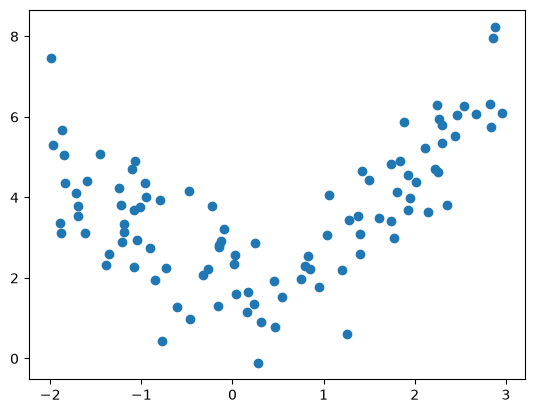

In [150]:
m=100
x=5*np.random.rand(m,1)-2
y=0.7* x ** 2 - 0.2 * x + 2 + np.random.randn(m, 1)

plt.scatter(x,y)

In [151]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

In [152]:
def get_pred_ridge(x,y,alpha):
    model=Pipeline(
    [
        ("polynomial feature",PolynomialFeatures(degree=16)),
        ("ridge reg",Ridge(alpha=alpha))
    ]
    )
    model.fit(x,y)
    return model.predict(x)

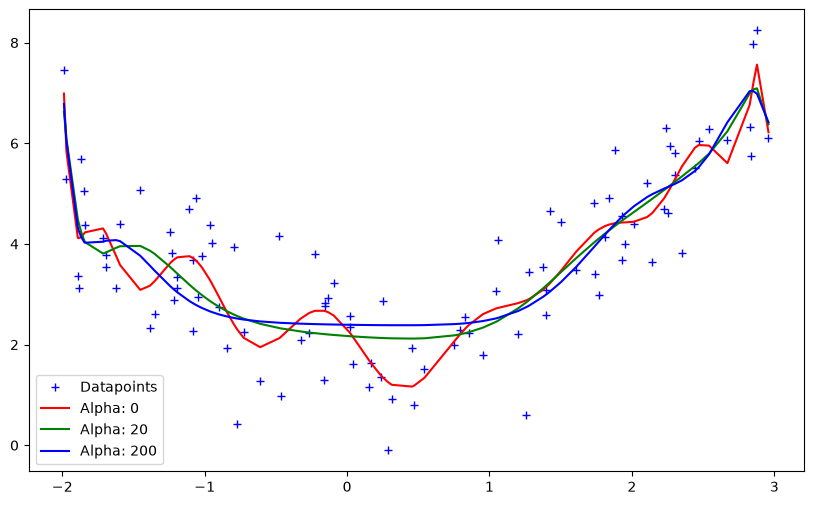

In [153]:
alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_pred_ridge(x, y, alpha)
    # Plot
    plt.plot(sorted(x[:, 0]), preds[np.argsort(x[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

In [154]:

from sklearn.datasets import make_regression
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

In [155]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [156]:
from sklearn.linear_model import Ridge
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.126913003523573


Implementation --- Simple Ridge Reg

In [157]:
class MyRidgeReg:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.m=None
        self.b=None

    def fit(self,x_train,y_train):
        num=0
        den=0
        for i in range(x_train.shape[0]):
            num=num+(y_train[i]-np.mean(y_train))*(x_train[i]-x_train.mean())
            den=den+(x_train[i]-x_train.mean())*(x_train[i]-x_train.mean())

        self.m=num/(den+self.alpha)
        self.b=y_train.mean()-self.m*x_train.mean()

        print(self.m,self.b)

    def predict(self,x_test):
        return self.m*x_test+self.b

In [158]:
model=MyRidgeReg(alpha=10)
model.fit(x_train=X,y_train=y)

[24.9546267] [-2.126913]


Implementation -- Multiple Ridge Reg(nD Data)

In [159]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score


x,y = load_diabetes(return_X_y=True)

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=4)

from sklearn.linear_model import Ridge
reg = Ridge(alpha=0.1,solver='cholesky')
reg.fit(X_train,y_train)


y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)


0.46931288533098037
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [160]:
class MyRidgeReg:
    def __init__(self,alpha=0.01):
        self.alpha=alpha
        self.coeff=None
        self.intercept=None

    def fit(self,X_train,y_train):
        
        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0]=0
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]

    def predict(self,x_test):
        return np.dot(X_test,self.coef_) + self.intercept_      

In [161]:
reg = MyRidgeReg()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.4667136517220699
[  38.87221436 -282.99890962  485.04798165  362.44102166 -419.23022085
  168.11031311  -18.84345801  203.84317074  594.02688454   37.92313953]
150.93769241774038
